In [28]:
# %autoreload
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from evoscape.landscapes import CellDiff_Dataset_Landscape
import evoscape.landscape_visuals as vis
from evoscape.module_helper_functions import transform_coords, rotate_landscape, landscape_from_timecode, modules_from_txt
from evoscape.morphogen_regimes import mr_linear_2signals
from matplotlib.colors import ListedColormap, BoundaryNorm, CenteredNorm, Normalize
import cmcrameri.cm as cm

from scripts.exp_description import *

from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor
from PIL import Image
import os

from matplotlib import style
style.use('default')

In [29]:

plt.rcParams.update({'figure.dpi': 200})  # Change to 200 for high res figures
plt.rcParams.update({'font.size': 15})  
plt.rcParams['axes.grid'] = False


In [51]:
data_dir = ('../alfyn_results_rev/saved_rev_2_slope_delta3_noise02/'
            'saved_files_rev_2_slope_delta3_noise02_4/CellDiff_Dataset_Landscape/')

panels_dir = '../panels/'

file_name = data_dir + 'optimization_log.csv'


log = np.genfromtxt(file_name, delimiter='\t', skip_header=1, names=['Timecode', 'Init_timecode', 'Fitness'], dtype=None, encoding='utf-8')
print(log.shape)

# fitness threshold for selecting
n_landscapes = 10
fitness_threshold = np.partition(log['Fitness'], -n_landscapes)[-n_landscapes]
print(fitness_threshold)

timecodes = log['Timecode'][log['Fitness'] >= fitness_threshold]
fitnesses = log['Fitness'][log['Fitness'] >= fitness_threshold]
print(len(timecodes))

(30,)
-0.8324080323809808
10


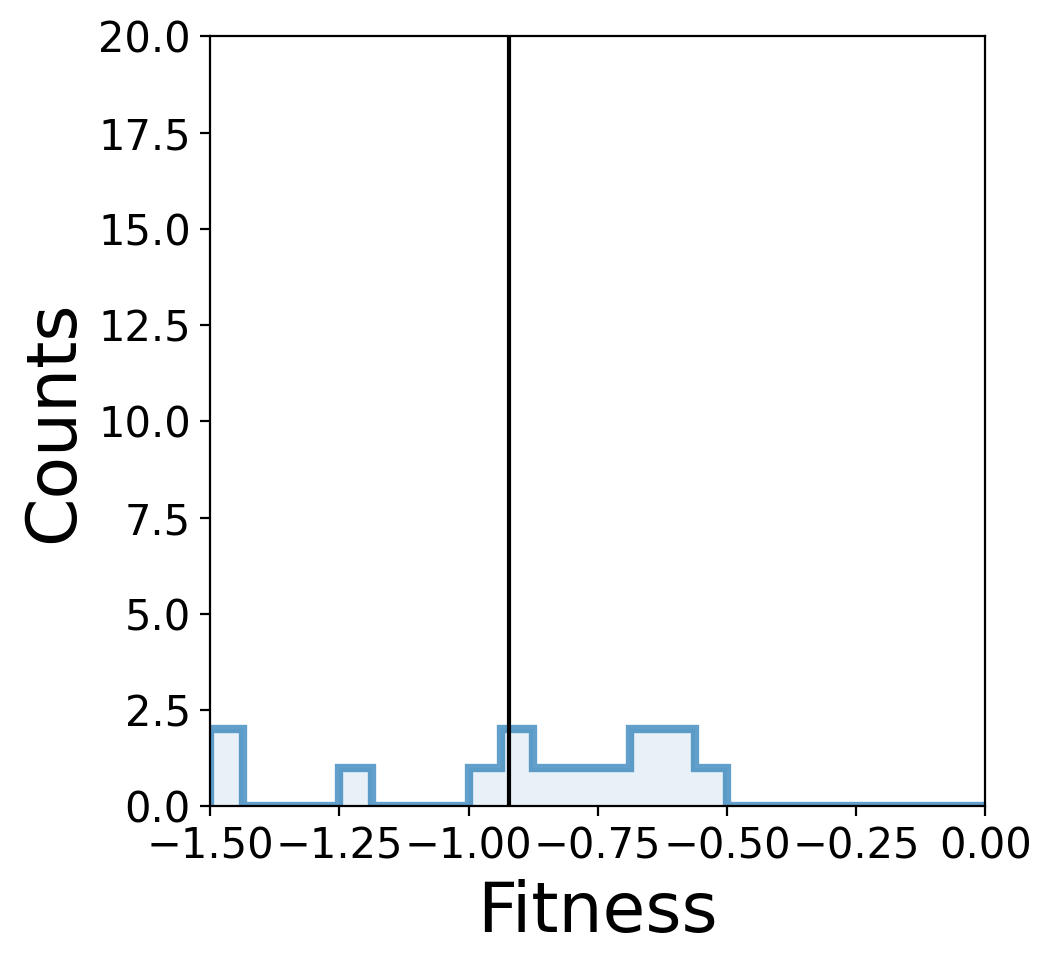

In [42]:
bins = np.linspace(-1.5, 0, 25)
plt.figure(figsize=(5,5))
plt.hist(log['Fitness'], bins=bins, density=False, alpha=0.1, histtype='stepfilled', lw=2, label='All')
plt.hist(log['Fitness'], bins=bins, density=False, alpha=0.7, histtype='step', linewidth=3, label='All', color='tab:blue')
plt.vlines(fitness_threshold, 0, 200, color='k')
plt.xlabel('Fitness', fontsize=25)
plt.ylabel('Counts', fontsize=25)
plt.ylim((0, 20))
plt.xlim((-1.5, 0))
plt.show()

In [36]:
def insert_sample_slide(pptx_path, data_dir, index, timecode):
    # Init presentation
    if not os.path.exists(pptx_path):
        prs = Presentation()
        prs.slide_width = Inches(16)
        prs.slide_height = Inches(9)
    else:
        prs = Presentation(pptx_path)

    slide = prs.slides.add_slide(prs.slide_layouts[6])  # blank

    # Title
    title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.2), Inches(15), Inches(0.5))
    text_frame = title_box.text_frame
    text_frame.text = f"{index:02d} — Timecode: {timecode}"
    p = text_frame.paragraphs[0]
    p.font.size = Pt(24)
    p.font.bold = False
    p.font.name = "Aptos"
    p.alignment = PP_ALIGN.LEFT
    p.font.color.rgb = RGBColor(0, 0, 0)

    # Layout constants
    margin_x = Inches(0.5)
    margin_y = Inches(0.8)
    spacing_x = Inches(0.2)
    spacing_y = Inches(0.1)
    fixed_height = Inches(2.7)  # consistent for all images

    # Row 1
    top_y1 = margin_y
    top_y2 = top_y1 + fixed_height - Inches(0.2)
    top_y3 = top_y2 + fixed_height

    idx = (1, 3, 2, 0, 4)
    loc = ((margin_x, top_y1), (margin_x+Inches(3), top_y1), (margin_x+Inches(6), top_y1),
           (margin_x, top_y2), (margin_x+Inches(3), top_y2))
    for i in range(5):
        filename = data_dir + timecode + '/result_landscape_' + str(idx[i]) +'.png'
        with Image.open(filename) as img:
            w, h = img.size
            left = w/3 + w*0.05
            right = 2*w/3
            cropped = img.crop((left, 0, right, h))

            temp_file = panels_dir + '/temp_cropped.png'
            cropped.save(temp_file)
        slide.shapes.add_picture(temp_file, *loc[i], height=fixed_height)

    idx = (1, 4)
    loc = ((margin_x, top_y3), (margin_x+Inches(5), top_y3),)
    for i in range(2):
        filename = data_dir + timecode + '/result_cell_trajectories_' + str(idx[i]) +'.png'
        slide.shapes.add_picture(filename, *loc[i], height=fixed_height)

    for j in range(7):
        filename = data_dir + timecode + '/result_proportions_' + str(j) + '.png'
        slide.shapes.add_picture(filename, Inches(12), margin_y+j*Inches(1.1), height=Inches(1.1))
    prs.save(pptx_path)

In [43]:

# for ind in range(60):
for ind in range(n_landscapes):
# for ind in (1,):
    timecode = timecodes[ind]
    insert_sample_slide(panels_dir+"Landscapes_linearized_02_6-8.pptx", data_dir, index=ind, timecode=str(timecode))


In [15]:
#  All experiments
morphogen_times = ((no_chir, fgf_no_pd),  # No Chir
                   (chir_2_3, fgf_no_pd),   # Chir 2-3
                   (chir_2_4, fgf_no_pd),  # Chir 2-4
                   (chir_2_5, fgf_no_pd),  # Chir 2-5
                   (chir_2_5, fgf_0_3),    # Ch 2-5 FGF 0-3
                   (chir_2_5, fgf_0_4),    # Ch 2-5 FGF 0-4
                   (chir_2_5, fgf_0_5),    # Ch 2-5 FGF 0-5
                   )
time_pars = (0., delta * 7, 8)

(30,)
-0.8902249198526908
10
1.0 0.0


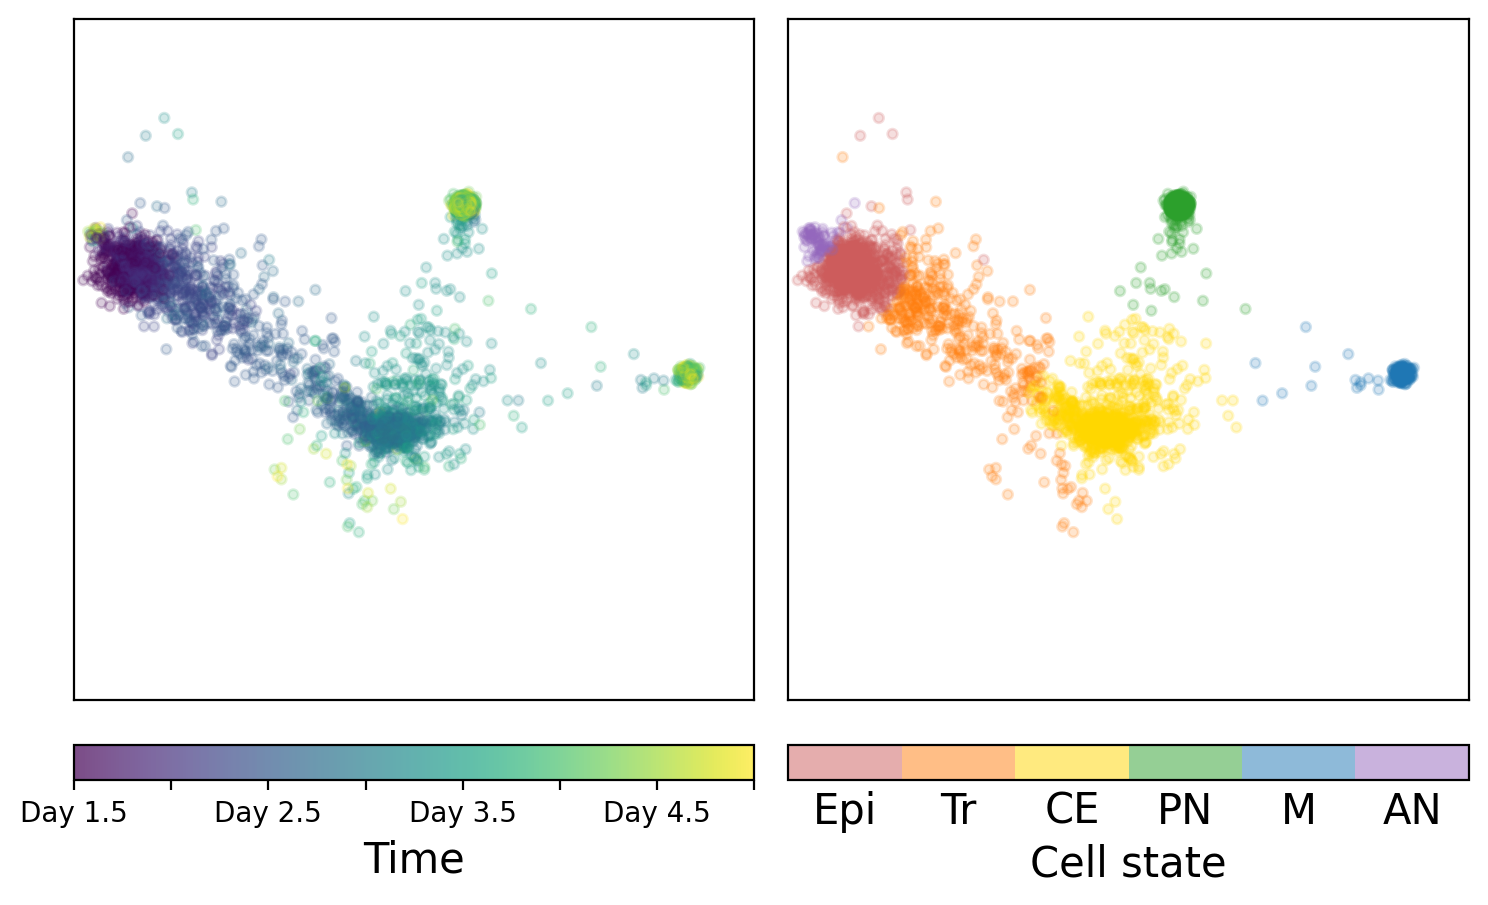

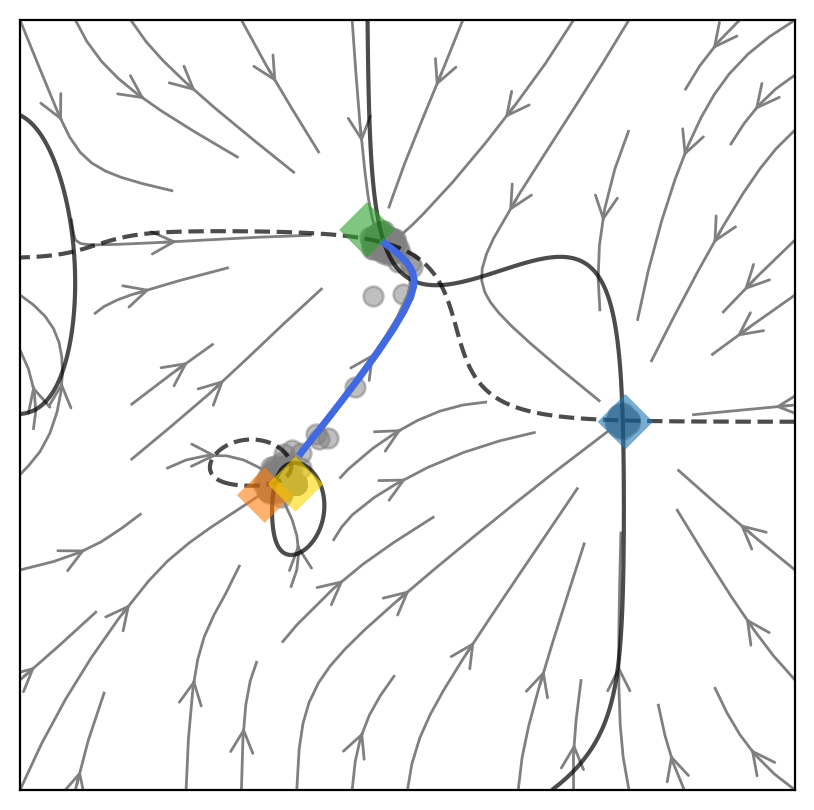

1.0 0.04166666666666667


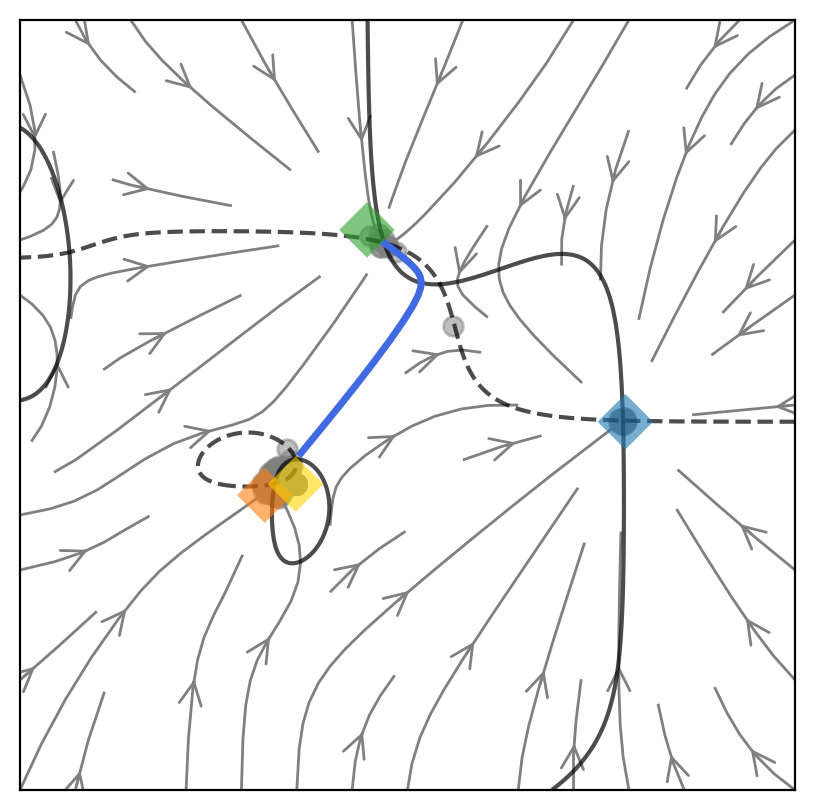

1.0 0.08333333333333334


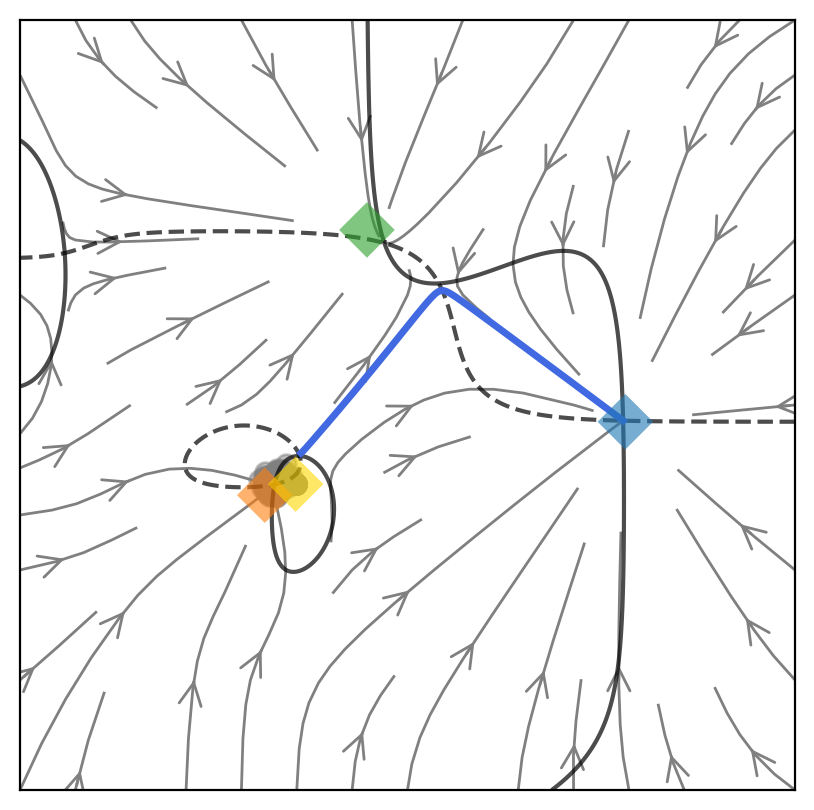

1.0 0.125


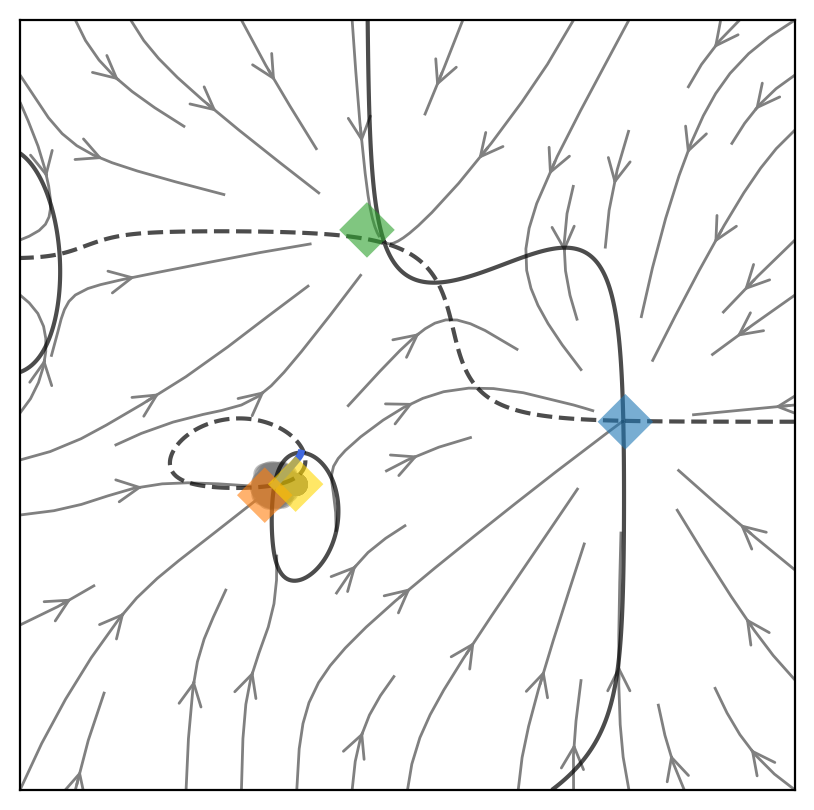

1.0 0.16666666666666669


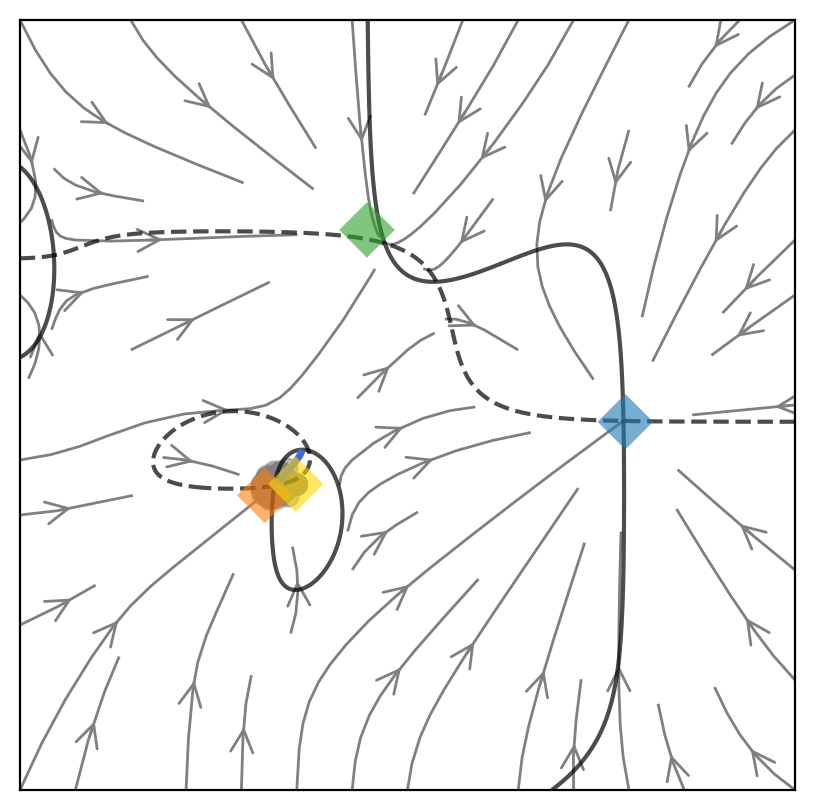

1.0 0.20833333333333331


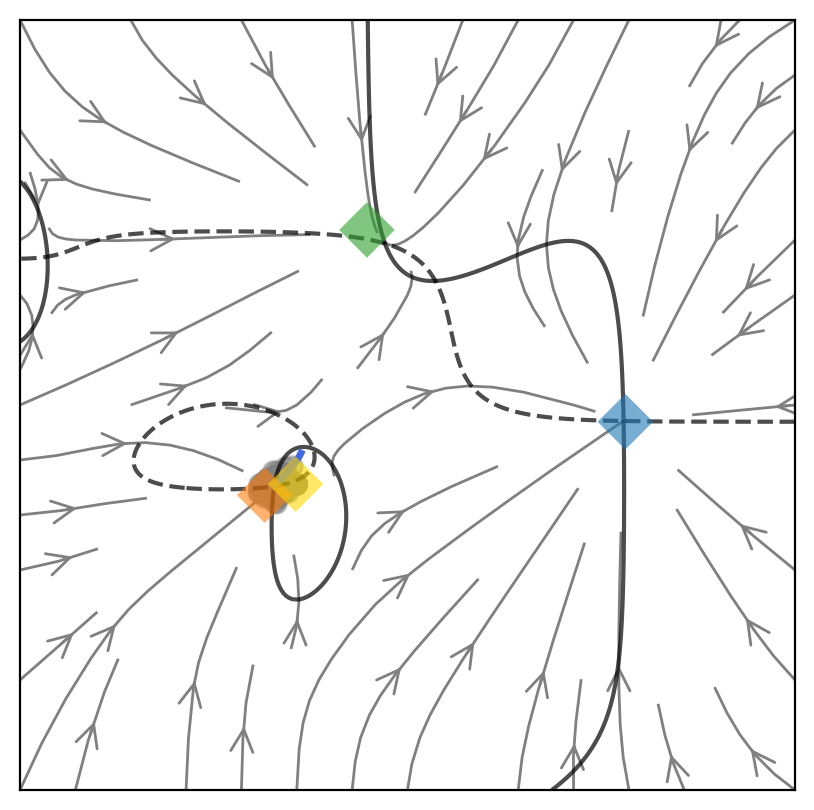

1.0 0.25


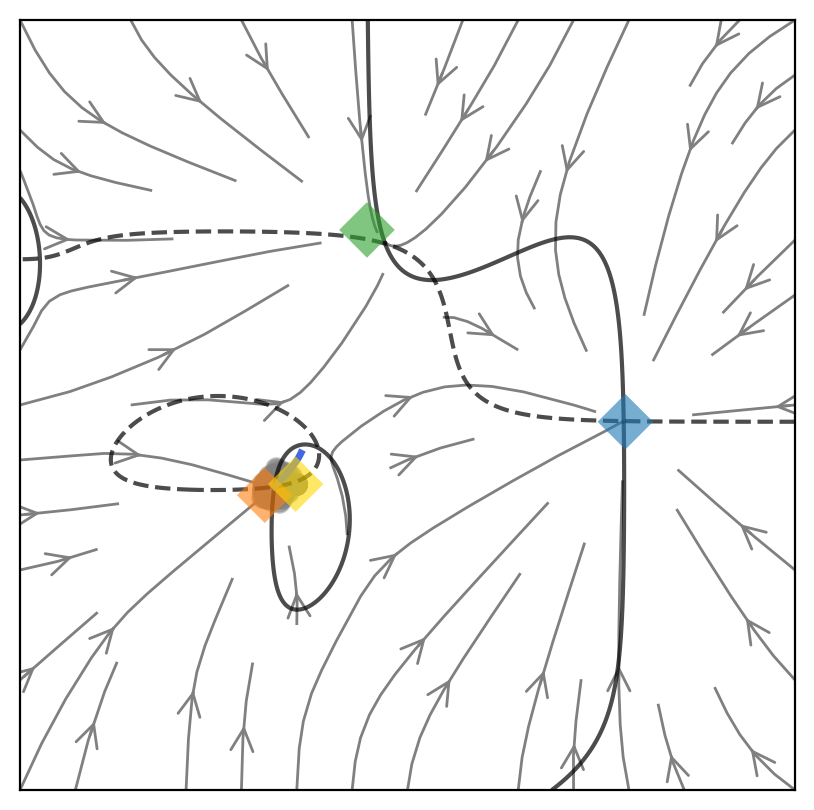

1.0 0.2916666666666667


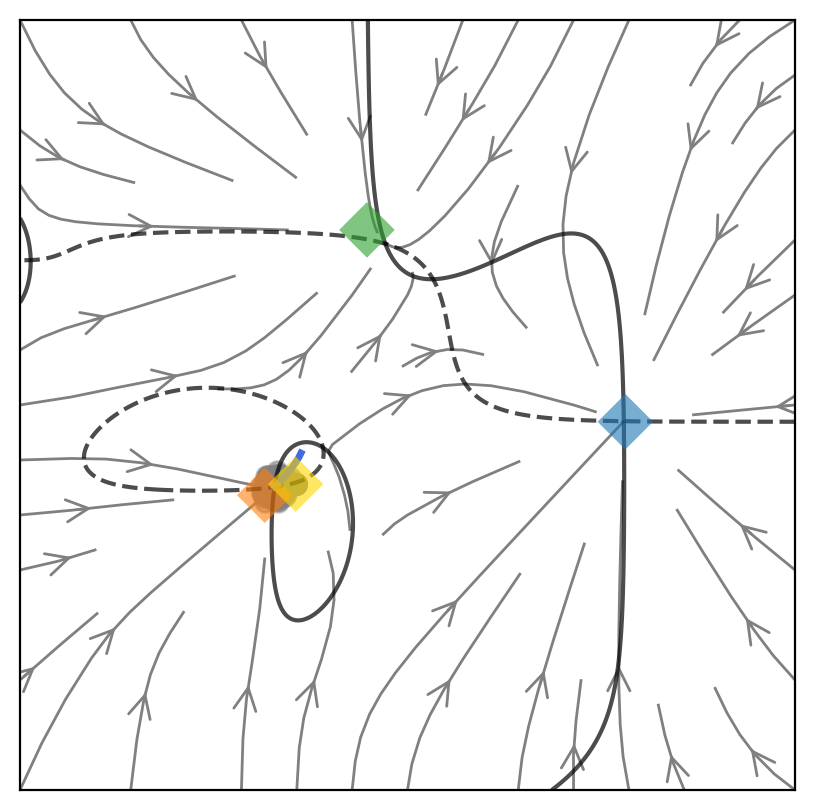

1.0 0.33333333333333337


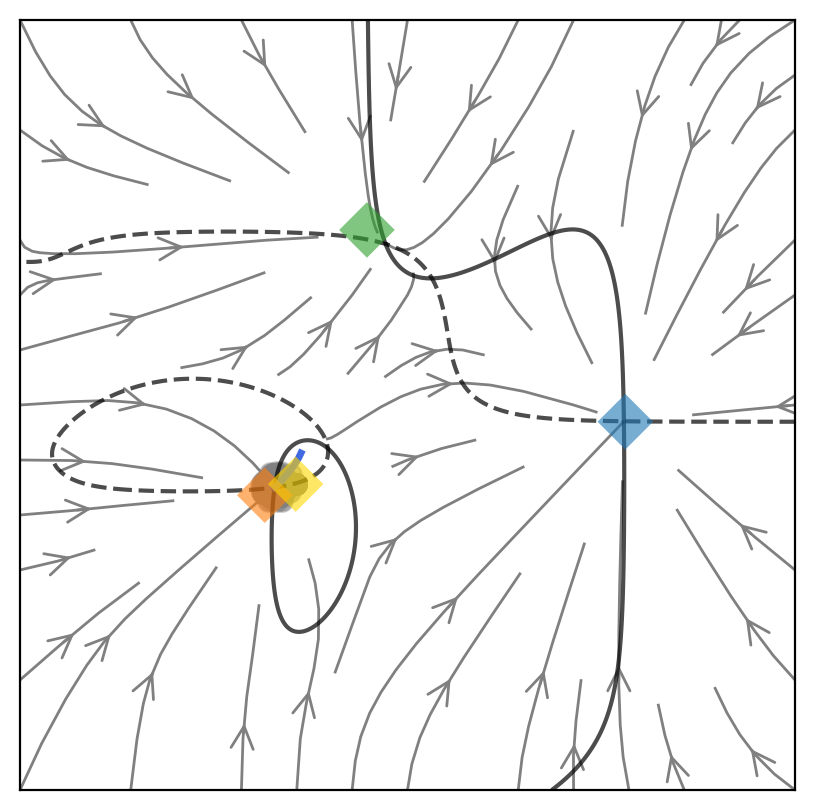

1.0 0.375


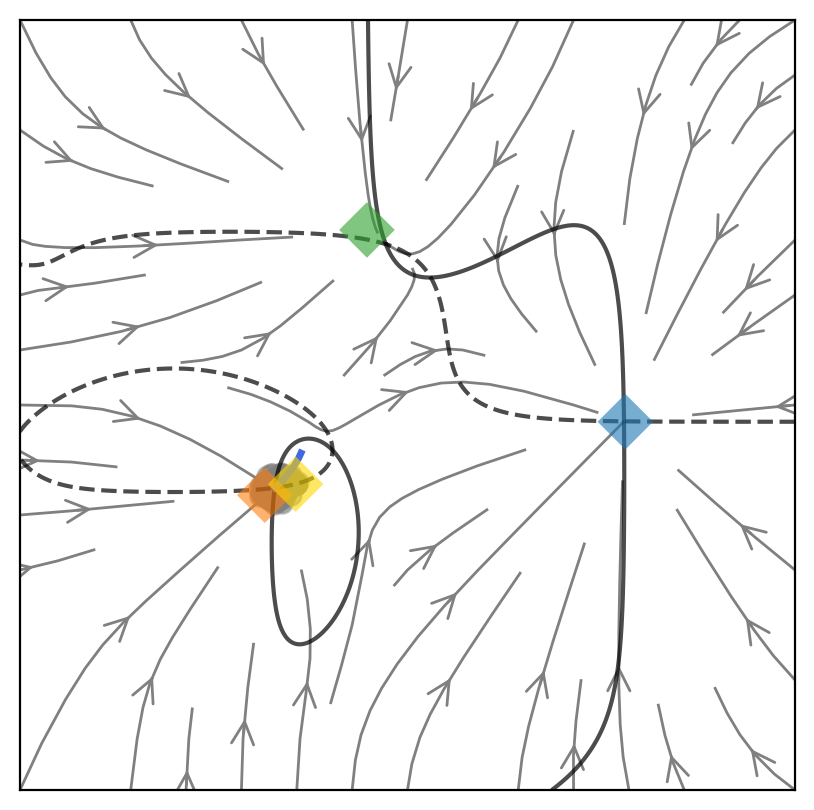

1.0 0.41666666666666663


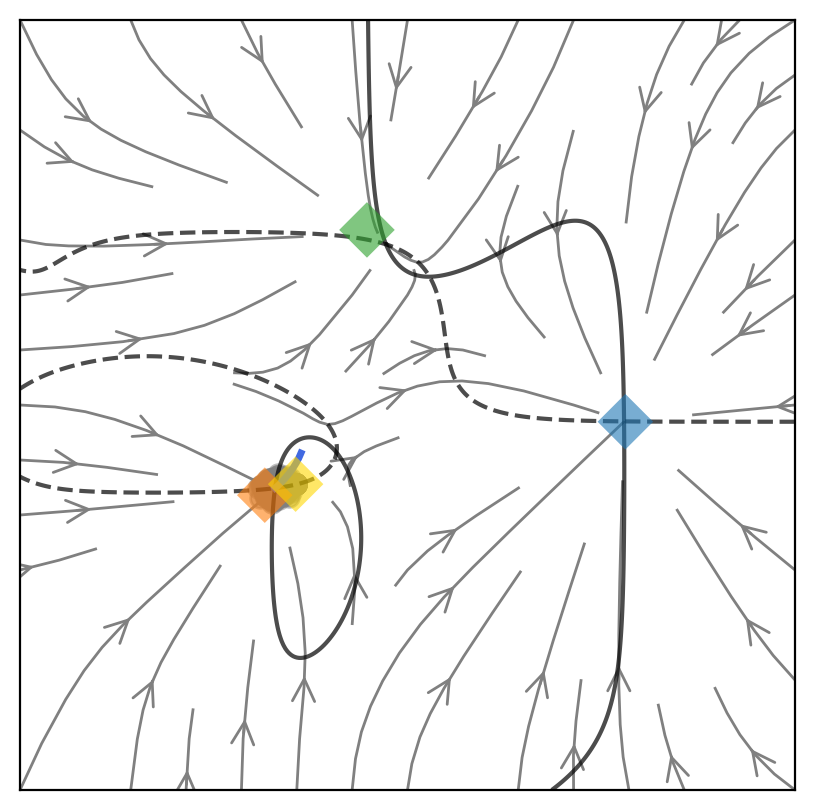

1.0 0.45833333333333337


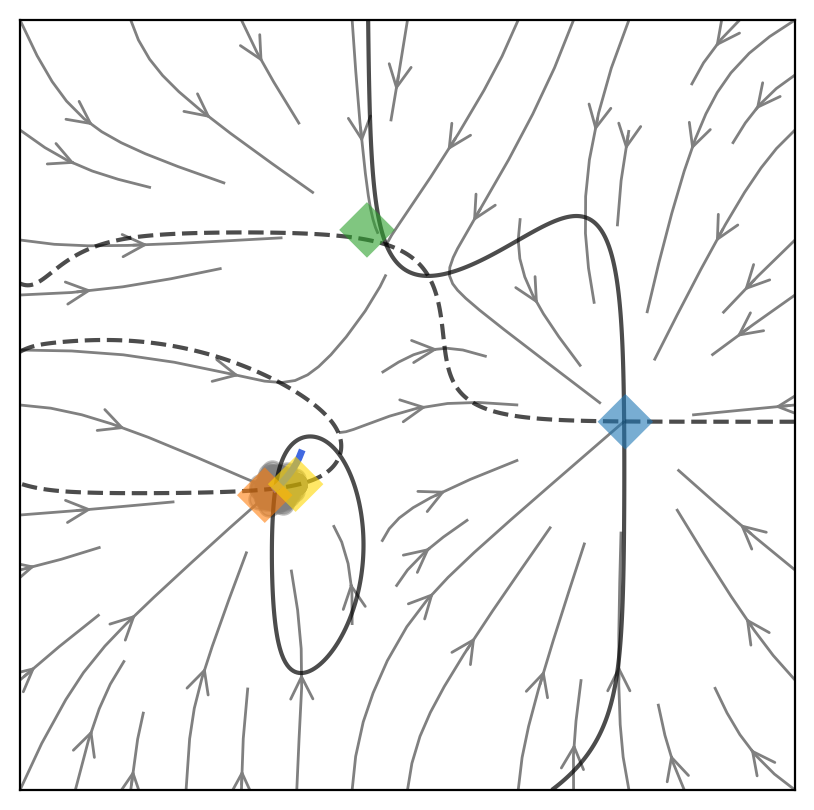

1.0 0.5


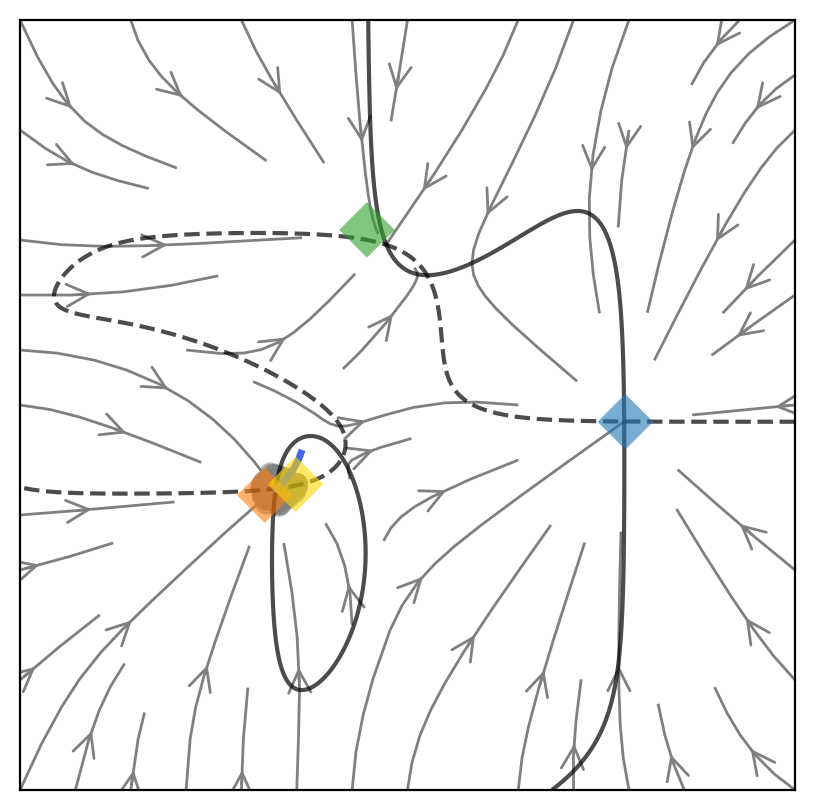

1.0 0.5416666666666666


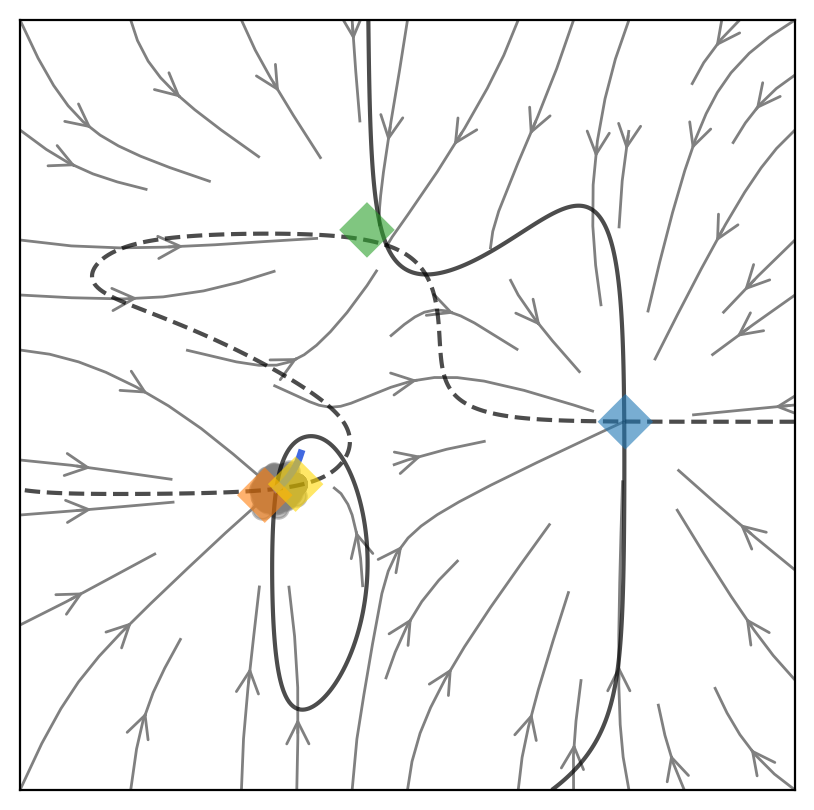

1.0 0.5833333333333334


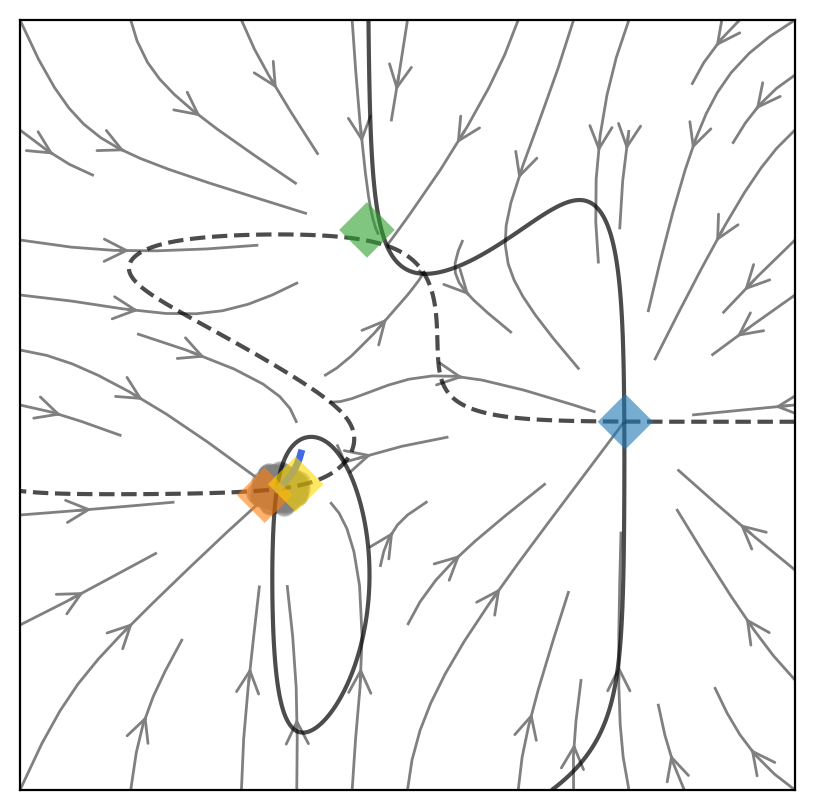

1.0 0.625


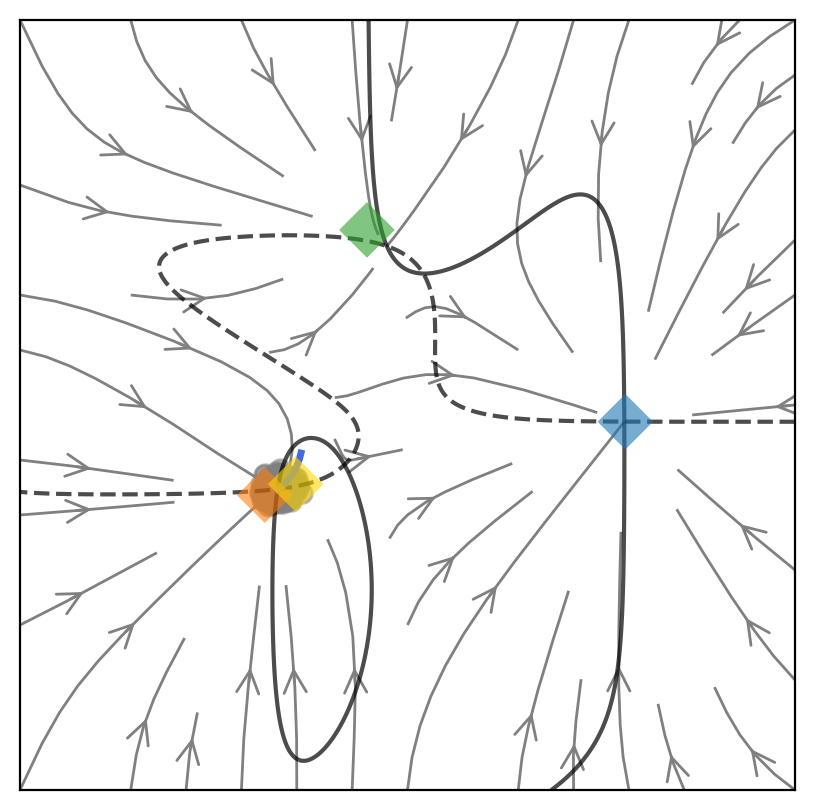

1.0 0.6666666666666667


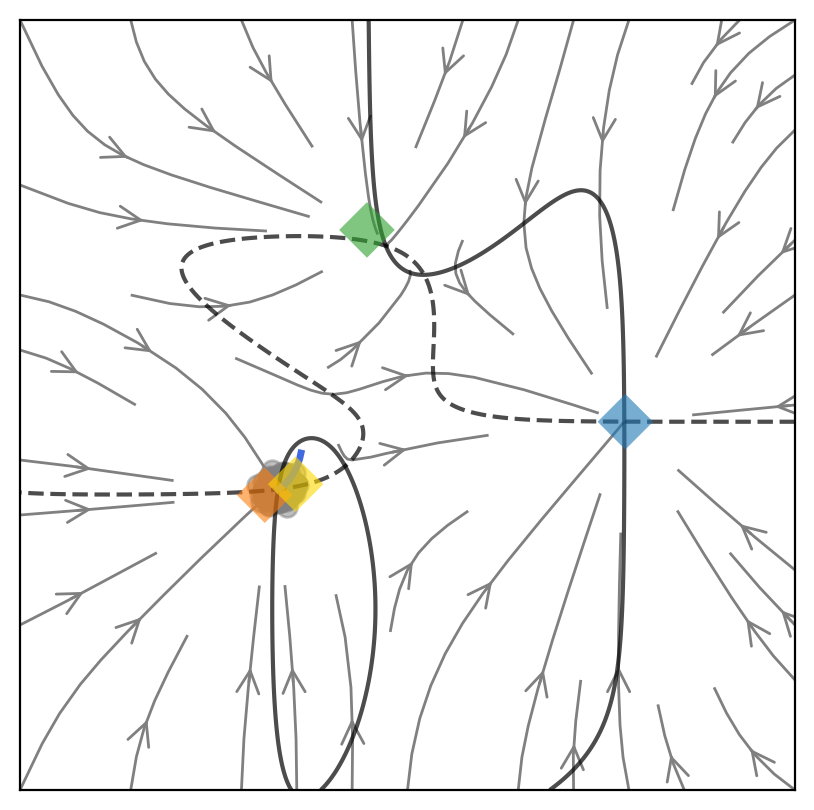

1.0 0.7083333333333334


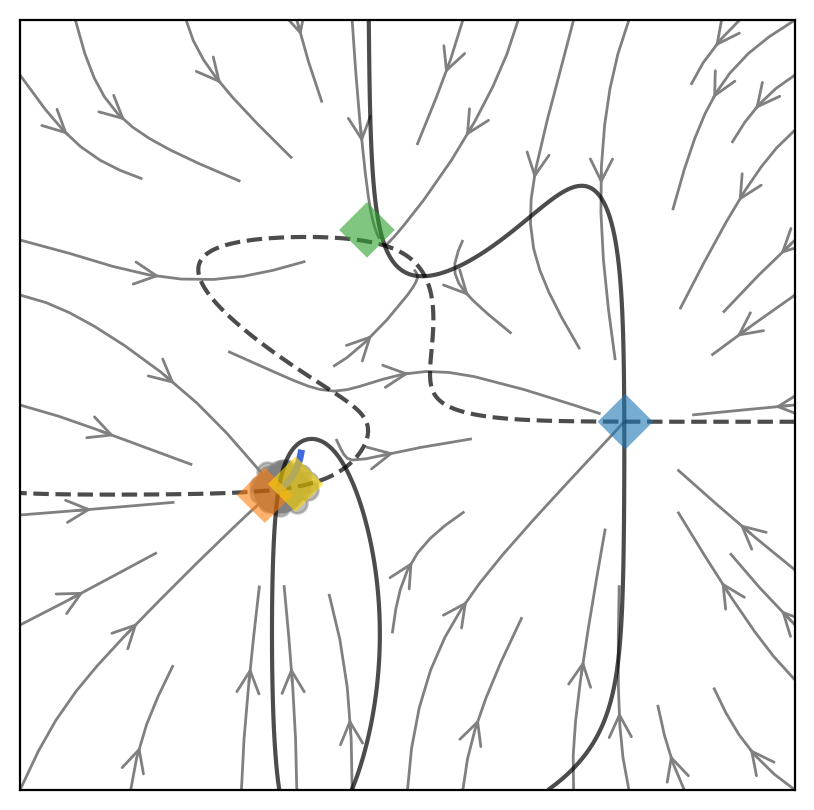

1.0 0.75


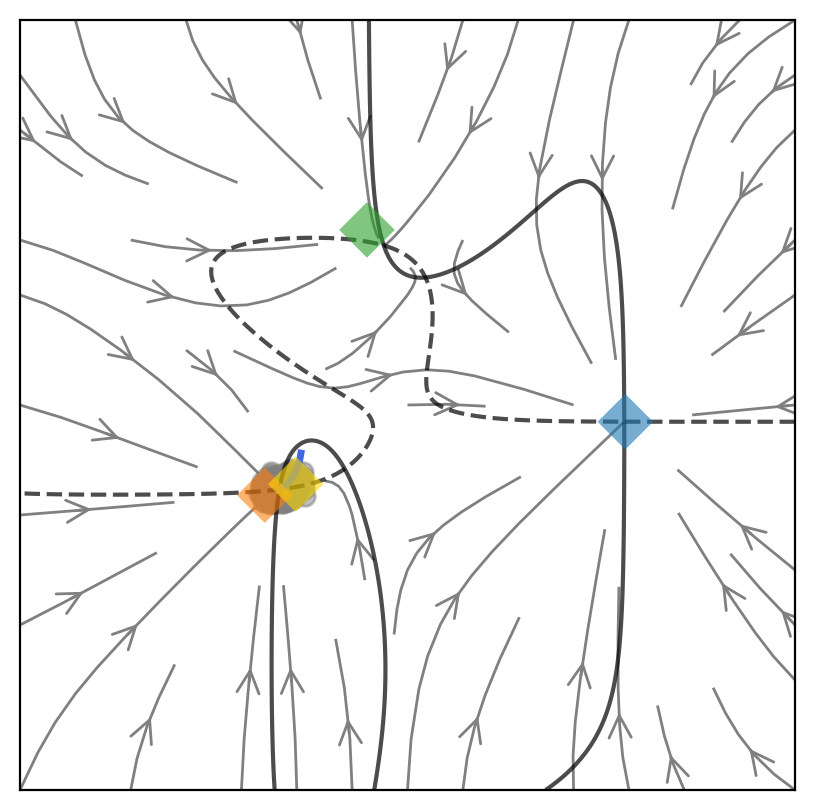

1.0 0.7916666666666667


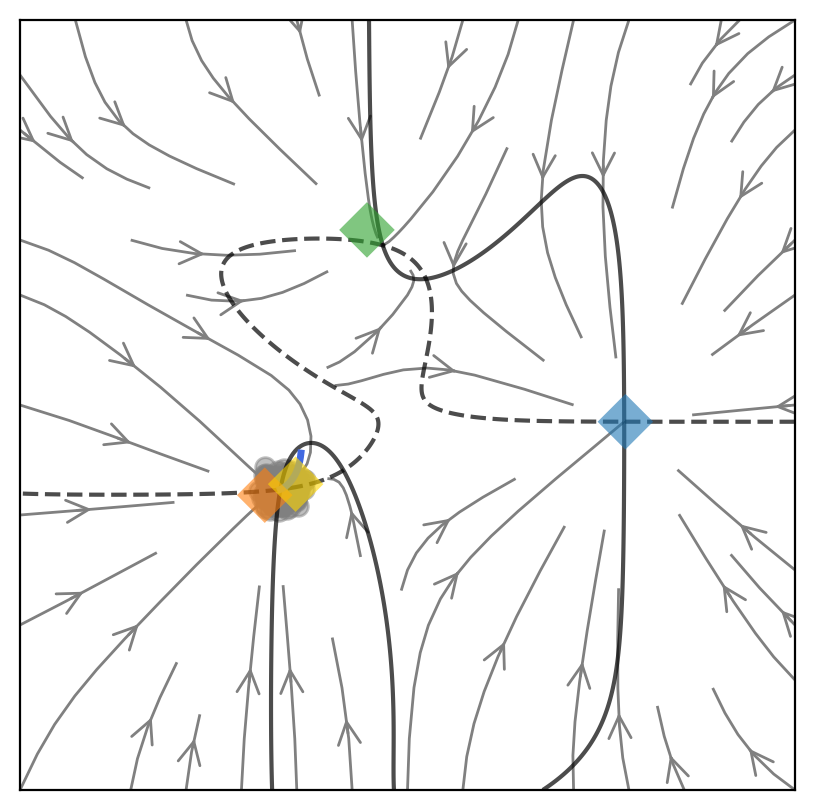

1.0 0.8333333333333333


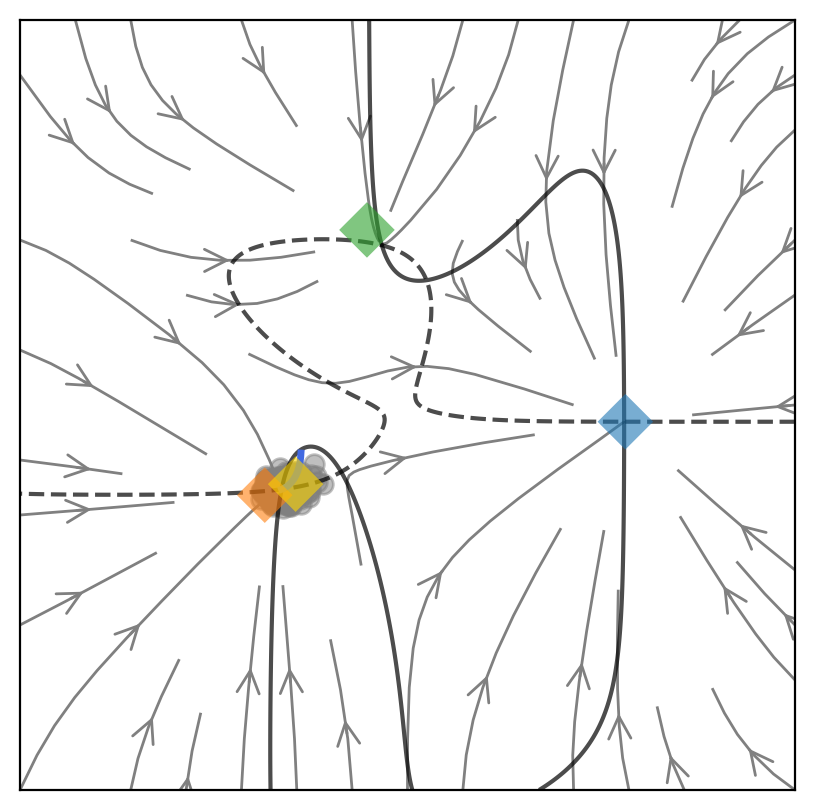

1.0 0.875


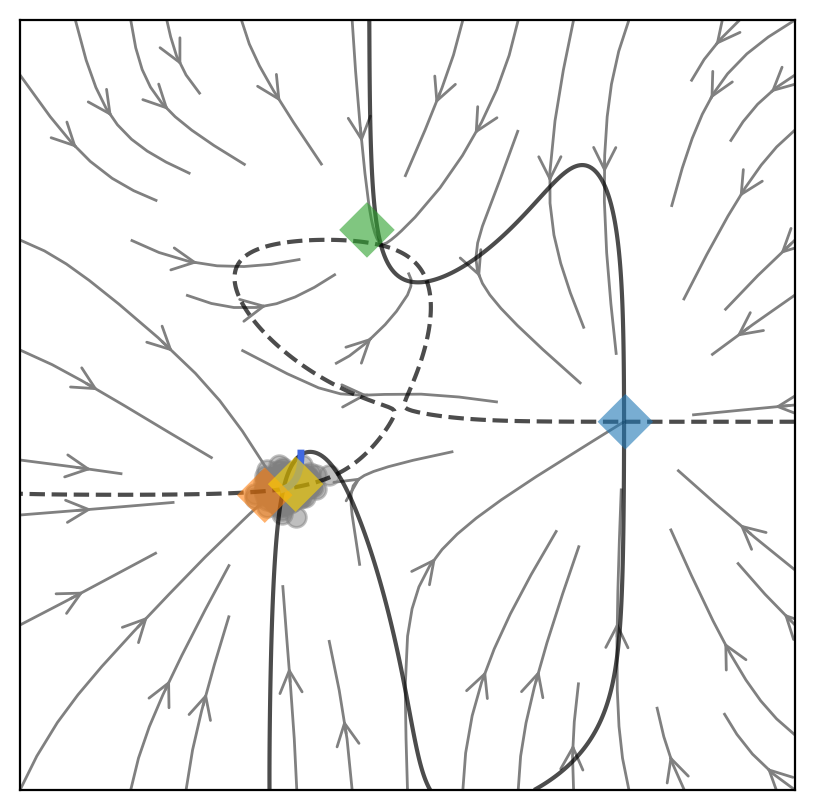

1.0 0.9166666666666667


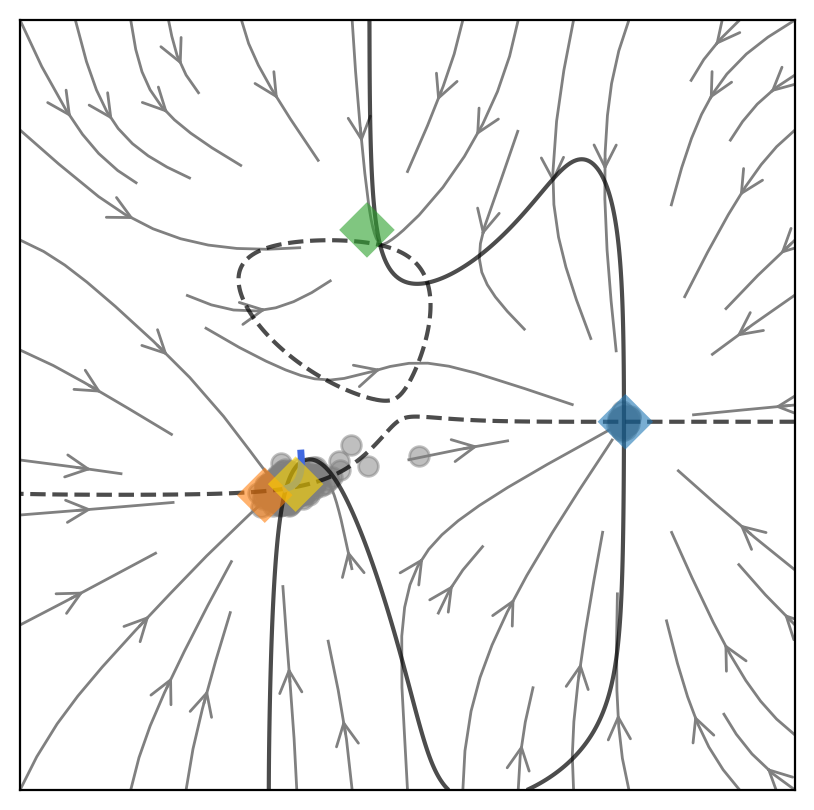

1.0 0.9583333333333333


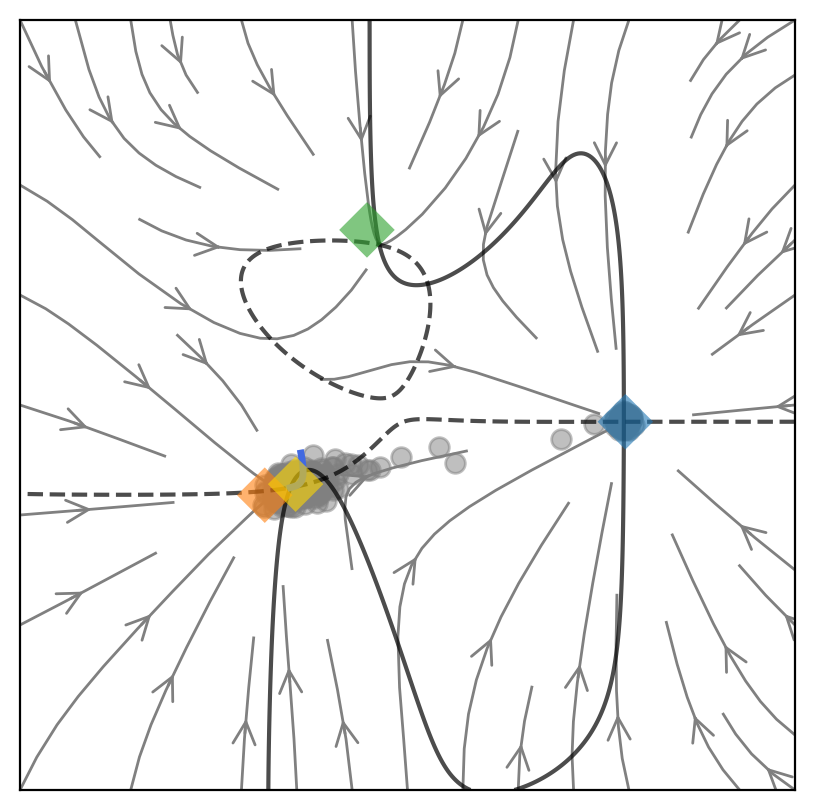

1.0 1.0


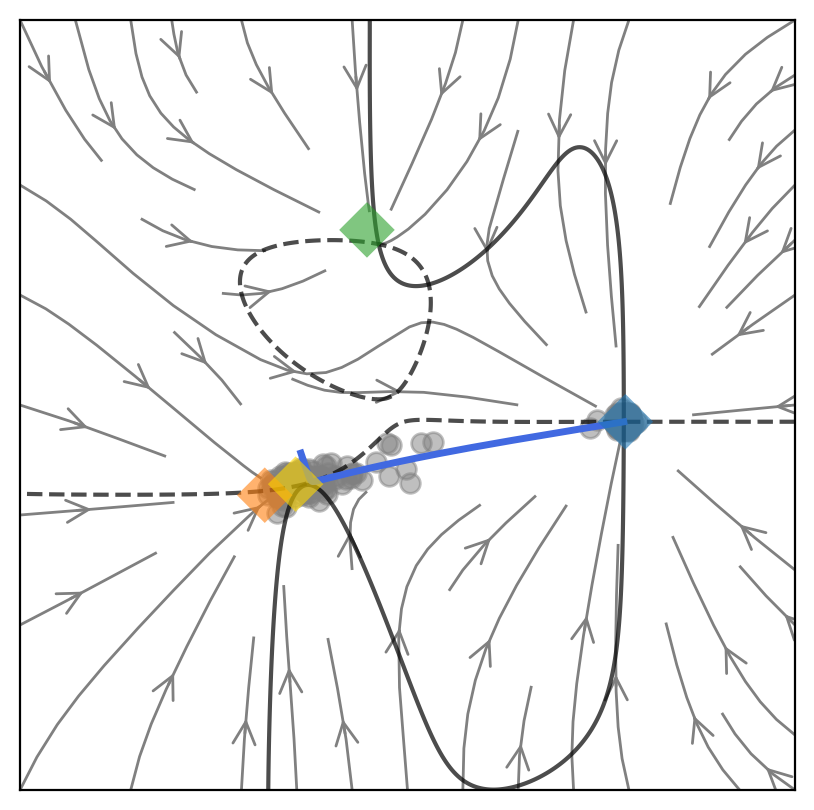

In [129]:
data_dir = ('../alfyn_results_rev/saved_rev_2_slope_delta3_noise02/'
            'saved_files_rev_2_slope_delta3_noise02_3/CellDiff_Dataset_Landscape/')
file_name = data_dir + 'optimization_log.csv'
log = np.genfromtxt(file_name, delimiter='\t', skip_header=1, names=['Timecode', 'Init_timecode', 'Fitness'], dtype=None, encoding='utf-8')
print(log.shape)

# fitness threshold for selecting
n_landscapes = 10
fitness_threshold = np.partition(log['Fitness'], -n_landscapes)[-n_landscapes]
print(fitness_threshold)
timecodes = log['Timecode'][log['Fitness'] >= fitness_threshold]
fitnesses = log['Fitness'][log['Fitness'] >= fitness_threshold]
print(len(timecodes))
# _______________________________________
# timecode = '20250903-073126'   # from 02_2
# timecode = '20250902-200151'  # from 02_1
timecode = '20250912-032346'  # from 02_3

# timecode = '20250914-230721' # from 02_6 # no flip
# timecode = '20250914-201058' # from 02_6
#
# timecode = '20250915-200629' # from 02_8
# timecode = '20250912-232530'# from 02_4



gen = 300

landscape_pars = {
    'A0': 0.005,
    'init_cond': (0., 0.),
    'regime': mr_linear_2signals,
    'n_regimes': 3,  # !
    'morphogen_times': None,
}

L = 4.   # !!!
npoints = 401
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q+1,q, indexing = 'xy')

origin = 2
direction = (3,4)
right = None
bottom = 4
left = 0

delta=3.
noise = 0.2
ndt = 50
state_names = ('Epi', 'Tr', 'CE', 'PN', 'M', 'AN')
colors = ('indianred', 'tab:orange', 'gold', 'tab:green', 'tab:blue', 'tab:purple')

time_pars = (0., delta*7, 15)

landscape = landscape_from_timecode(CellDiff_Dataset_Landscape, timecode, data_dir, gen, landscape_pars)
# landscape = rotate_landscape(landscape, origin=origin, direction=direction,
#                              left=left, right=right, bottom=bottom)
# landscape.morphogen_times = morphogen_times[4]  # exp 5
landscape.morphogen_times = morphogen_times[1]  # exp 2

landscape.init_cells(300, 0, noise)
fig0 = vis.get_and_plot_traj(landscape, *time_pars, 4., noise, ndt = ndt, s=12, state_names=state_names,
                                t_ticks = (0, delta*7, 8),
                                t_names=('Day 1.5', '', 'Day 2.5', '', 'Day 3.5', '', 'Day 4.5', ''),)
                                # t_names=('', 'Day 2', '', 'Day 3', '', 'Day 4', '', 'Day 5'),)
ax = fig0.axes
ax[0].set_ylim((-4., 4))
ax[1].set_ylim((-4., 4))

def chir_const(t):
    return 1.
def fgf_ramp(t):
    return t/delta/7. * 1.
landscape.morphogen_times = (chir_const, fgf_ramp)

times = np.linspace(0, 7., 25)*delta
for t in times:
    landscape.init_cells(30, 2, 0.)
    traj, states = landscape.run_cells(*time_pars, noise=0.2, frozen=True, t_freeze=t, ndt=100)
    print(landscape.morphogen_times[0](t), landscape.morphogen_times[1](t))
    fig = vis.visualize_landscape_t(landscape, xx, yy, t, color_scheme='order', circle_opacity=0.22, circles=False)
    plt.scatter(traj[0, :, :], traj[1, :, :], alpha=0.5, c='grey', s=50)

    landscape.init_cells(1, (-0.1, -0.5), 0.)
    traj, states = landscape.run_cells(0., 3*delta, 201, noise=0., frozen=True, t_freeze=t, ndt=50)
    plt.plot(traj[0, 0, :], traj[1, 0, :], 'royalblue', lw=2.5)
    for im, module in enumerate(landscape.module_list):
            plt.scatter(module.x, module.y, c=colors[im], marker='D', s=200, edgecolor='None', alpha=0.6, zorder=10)
    plt.show()

In [21]:
print(landscape)

Landscape with modules:
Node: x=-3.3526191883043626; y=1.0599224018545428; a=[ 7.35823767e-03,-1.25772228e+01, 1.55806304e+00]; s=[ 0.47053498,-0.68273649, 0.12649222],
Node: x=-0.47346599996689176; y=-0.9369175157766958; a=[ 0.77569800,10.65706712,-8.96861338]; s=[0.22842593,0.15262523,0.83084944],
Node: x=-0.15513574612723602; y=-0.8224118573194708; a=[  1.89800548, -8.24120247,-11.04024873]; s=[ 0.40734114,-0.31476489, 0.52261247],
Node: x=0.5816000909573606; y=1.8190678865670882; a=[12.75697223,-2.70977224,-1.18222868]; s=[ 1.13760975,-0.01011045,-0.32037539],
Node: x=3.2488054347655435; y=-0.17395507685592548; a=[ 19.92788185,  8.48796981,-13.64613643]; s=[0.93055072,0.43192558,0.08141097],
Node: x=-3.8465930965323922; y=1.5327676466670805; a=[11.80680986,-9.04670722,-5.28402638]; s=[ 1.18013935,-0.36182813,-0.97084285]


0.0 1.0


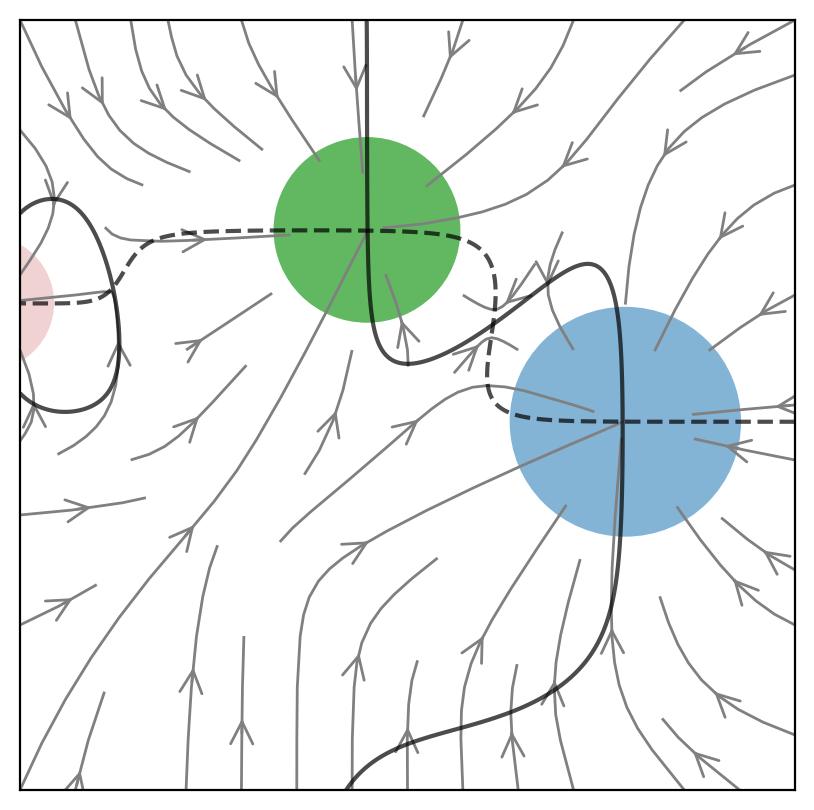

1.0 1.0
0.0


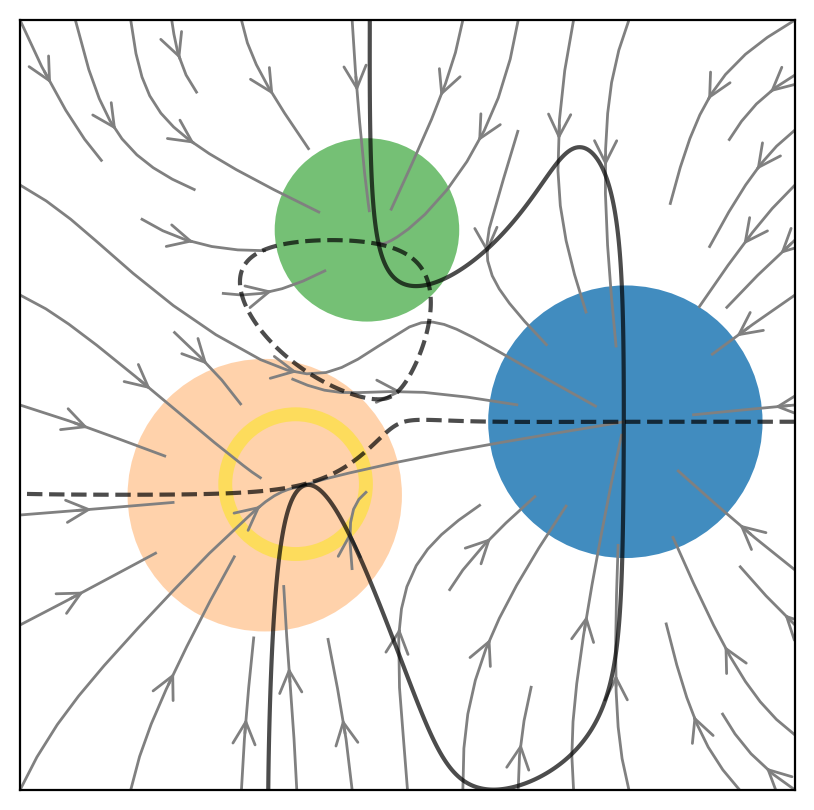

1.0 0.0
0.0


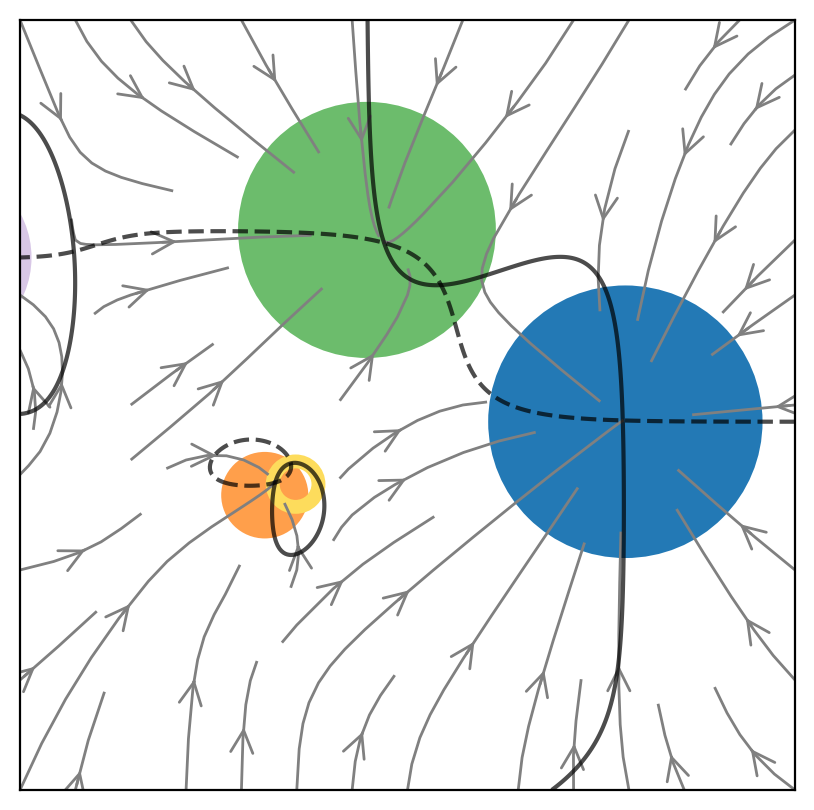

1.0 0.9
0.0


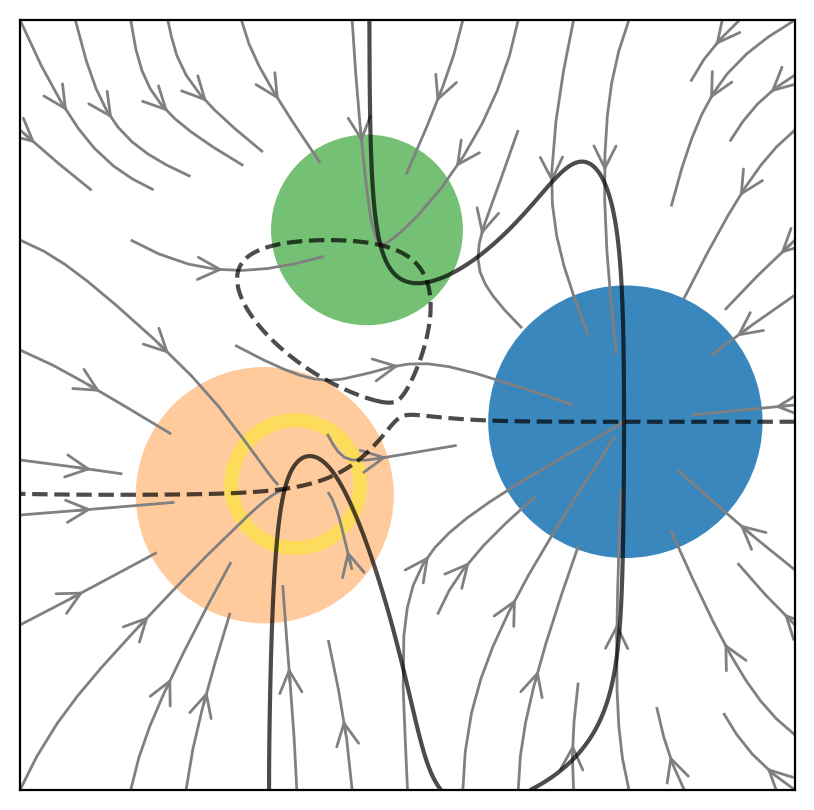

0.0 0.9
0.0
0.0 0.0


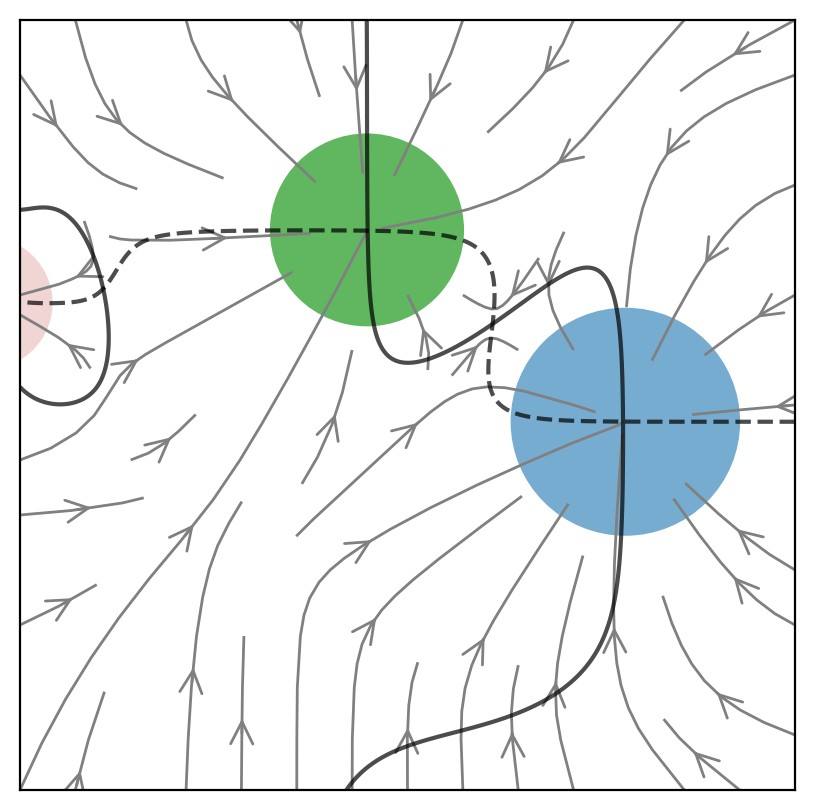

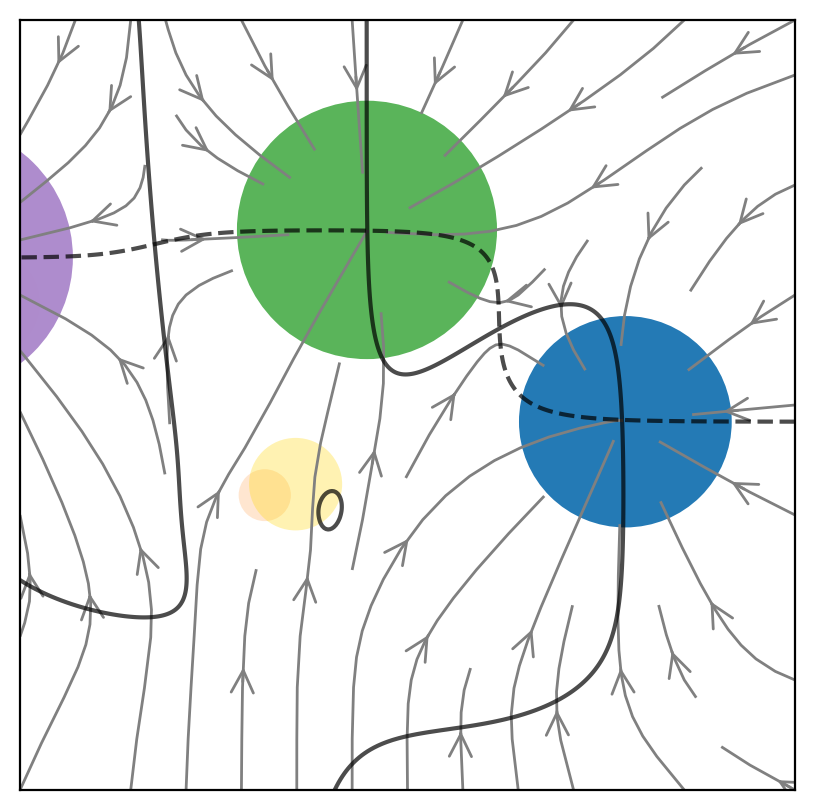

In [127]:





# __________Plot all conditions ____________
landscape.morphogen_times = (chir_2_5, fgf_0_3)
times = (delta*0., delta*2., delta*4.)
for t in times:
    print(landscape.morphogen_times[0](t), landscape.morphogen_times[1](t))
    fig, ax = vis.visualize_landscape_t(landscape, xx, yy, t, color_scheme='order', circle_opacity=0.22)
    ax = fig.axes[0]
    # for im, module in enumerate(landscape.module_list):
    #     plt.scatter(module.x, module.y, c=colors[im], marker='D', s=200, edgecolor='None', alpha=0.6, zorder=10)
    if t > 0:
        module = landscape.module_list[2]
        V, sig, A = module.get_current_pars(t, landscape.regime, *landscape.morphogen_times)
        print(A)
        circ = plt.Circle((module.x, module.y), 1.18 * float(sig), color='xkcd:light gold',
                          fill=False, alpha=1., clip_on=True, linewidth=5)
        ax.add_patch(circ)

    plt.show()
landscape.morphogen_times = (chir_2_4, fgf_no_pd)
times = (delta*4., delta*6.)
for t in times:
    print(landscape.morphogen_times[0](t), landscape.morphogen_times[1](t))
    fig, ax = vis.visualize_landscape_t(landscape, xx, yy, t, color_scheme='order', circle_opacity=0.22)
    module = landscape.module_list[2]
    V, sig, A = module.get_current_pars(t, landscape.regime, *landscape.morphogen_times)
    print(A)
    if t < delta*5:
        circ = plt.Circle((module.x, module.y), 1.18 * float(sig), color='xkcd:light gold',
                          fill=False, alpha=1., clip_on=True, linewidth=5)
        ax.add_patch(circ)
        # for im, module in enumerate(landscape.module_list):
        #     plt.scatter(module.x, module.y, c=colors[im], marker='D', s=200, edgecolor='None', alpha=0.6, zorder=10)
        plt.show()

landscape.morphogen_times = (no_chir, fgf_0_3)
times = (delta*6.,)
for t in times:
    print(landscape.morphogen_times[0](t), landscape.morphogen_times[1](t))
    fig, ax = vis.visualize_landscape_t(landscape, xx, yy, t, color_scheme='order', circle_opacity=0.22)
    module = landscape.module_list[2]
    # V, sig, A = module.get_current_pars(t, landscape.regime, *landscape.morphogen_times)
    # print(A)
    # circ = plt.Circle((module.x, module.y), 1.18 * float(sig), color='gold',
    #                   fill=False, alpha=0.7, clip_on=True, linewidth=4)
    # ax.add_patch(circ)
    # # for im, module in enumerate(landscape.module_list):
    # #     plt.scatter(module.x, module.y, c=colors[im], marker='D', s=200, edgecolor='None', alpha=0.6, zorder=10)
    # plt.show()